# Conformance & Curtailment Analysis (Solar Analytics)

**Purpose:** 
1. Read the conformance/curtailment result tables produced by the inherited `SolA2024_Analysis` pipeline, 
2. compute the fleet-level headline numbers, and 
3. *replicate* the per-interval conformance logic transparently on a single site so the table values can be verified from scratch.

**What this notebook does NOT do:** it does not rebuild the result tables (that is the
Trino job in `Volt-*-Trino.ipynb`). Everything here reads existing Iceberg
`conformance_*` tables via Athena (`aq`) and reproduces the metric definitions in
readable SQL/pandas. No Trino cluster required.

---

### Result lineage

There are **two** generations of results in the bucket:

| Lineage | DB | Built by | Cohort | Status |
|---|---|---|---|---|
| `conformance_*` (Iceberg) | `solar_analytics_iceberg` | Trino notebooks | **full** `meta_up23c` is_pv fleet | newer |
| `compliance_*` (Hive) | `solar_analytics` | Spark `Volt-Watt.ipynb` etc. | single-inverter, validated capacity | older |

- The report's **16,148-site** figure corresponds to the *single-inverter, validated-capacity* cohort (the Hive/`meta_single_inverters` path), 
- **not** the full fleet the Iceberg tables are computed on. 
- This notebook reads the Iceberg `conformance_*` tables and allows restriction to a single-inverter cohort (Section 2.4) to approach that figure.

### Metric definitions recovered from past SQL queries under SolA2025_Analysis

- **Per-interval grain:** telemetry collapsed circuit->site by
  `P_kW = sum(power*circuit_polarity)/1000`, `Q_kvar = sum(energy_reactive*circuit_polarity)/1000*12`,
  `V = avg(voltage)` (sustained-op/anti-island use `max(voltage)`), `S_rated = ac_capacity_kw`.
  Units: `power` is **W**; `energy_reactive` is **var.h per 5-min interval** (hence x12 -> kvar).
  Sign convention assumed: **+Q = supplying, -Q = absorbing**.
- **Tolerance band:** +/-`0.04*S_rated` (4%). The report frames this as consistent with
  AS/NZS 4777.2 measurement allowance AND as absorbing the ~1% MSB-vs-inverter voltage offset
  (voltage is metered at the switchboard, not the inverter terminal).
- **Site conformant** if non-conforming intervals are **<= 10%** of evaluated intervals.
  NOTE: the milestone report headlines Volt-Watt as **% of sites with *any* non-conformance**
  plus a **capacity-normalised** rate, not the 10% rule (see Section 2.5). The 10% rule and the
  90% rule (EBM appendix) are project conventions; pick the one the write-up uses per mechanism.
- **Volt-VAr "reduced" non-conformance** = `Q_adverse + Q_inactive + Q_major_deficit`
  (excludes `minor_deviation` and `major_surplus`). The two middle category NAMES are swapped
  vs the colleague's notes (Section 2.1) and the report's Volt-VAr section is still in draft, so
  this is NOT yet settled — compute both.
- **Curtailment** is a kW shortfall vs the GHI counterfactual, summed per interval ->
  *5/60 h for kWh. Volt-Watt curtailment / GHI conformance exist for **2024 only** (NCI
  irradiance coverage is Jan-Dec 2024). Report headline: V-Watt curtailment < 0.6% of generation.
- **GHI counterfactual model — implementation vs documentation gap.** The report AND the
  colleague's notes describe regressing `P/P_cs` against **`GHI/GHI_cs`** in **5-min** time bins.
  The implemented SQL (`ghi_pv_estimator`) regresses `P_norm/P_norm_cs` against **raw GHI** in
  **30-min** bins. Confirm which is authoritative before quoting curtailment/uncurtailed figures.

In [39]:
# Setup
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

from aws_config import aq, dread, s3_ls, databases, tables, describe
SA  = "solar_analytics"            # Hive (older 'compliance_*')
SAI = "solar_analytics_iceberg"    # Iceberg (newer 'conformance_*')

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

In [40]:
# --- AS/NZS 4777.2:2020 Australia-A set-points + pipeline constants -----------
# Values mirror the colleague's notebooks so replicated metrics match the tables.
AS4777 = {
    # Volt-Watt: 100% S_rated at/below V1, ramp to 20% at V2
    "VW":   {"V1": 253.0, "V2": 260.0, "P1": 1.00, "P2": 0.20},
    # Volt-VAr: +Q1 supplying <=V1, 0 across deadband V2..V3, -Q4 absorbing >=V4
    "VVAR": {"V1": 207.0, "V2": 220.0, "V3": 240.0, "V4": 258.0, "Q1": 0.44, "Q4": 0.60},
    # Volt-VAr Q_impact category thresholds (signed measured/required ratio)
    "QIMP": {"thr1": -0.1, "thr2": 0.1, "thr3": 0.9, "thr4": 1.1},
    "TOL_FRAC":         0.04,   # +/-4% S_rated tolerance band, used everywhere
    "SITE_CONF_THRESH": 0.10,   # site conformant if nonconf fraction <= 10%
    "PV_ACTIVE_FRAC":   0.16,   # 'solar generating' = P_pv > 16% S_rated (denominator)
    "AI_V_BAND":        (260, 265),  # anti-islanding / stop-region voltage sweep
    "SUSTOP_V_BAND":    (253, 258),  # sustained-operation voltage sweep
    "INTERVAL_H":       5/60,   # 5-min interval -> hours, for kW-sum -> kWh
}

In [41]:
# Reference curves (lifted verbatim from PQRMs / Volt-*-Trino)
def get_max_P(V, Srated=1.0, vw=AS4777["VW"]):
    """Volt-Watt active-power ceiling (no tolerance)."""
    if V is None: return None
    v1, v2, p2 = vw["V1"], vw["V2"], vw["P2"]
    if V < v1:  return Srated
    if V > v2:  return p2*Srated
    return (Srated - p2*Srated)/(v1 - v2)*(V - v2) + p2*Srated

def get_voltvar_Q(V, Srated=1.0, vv=AS4777["VVAR"]):
    """Required Volt-VAr reactive power. +supplying / -absorbing."""
    v1, v2, v3, v4, Q1, Q4 = vv["V1"], vv["V2"], vv["V3"], vv["V4"], vv["Q1"], vv["Q4"]
    if V <= v1:  return  Q1*Srated
    if V <  v2:  return (Q1*Srated)/(v1 - v2)*(V - v2)
    if V <= v3:  return  0.0
    if V <  v4:  return -(0 - Q4*Srated)/(v3 - v4)*(V - v4) - Q4*Srated
    return -Q4*Srated

def Q_capability_absorbing(P, Srated=1.0):
    """Most the inverter can ABSORB given active power P (negative = absorbing)."""
    P = abs(P)
    if P <  0.2*Srated:  return 0.0
    if P <= 0.6*Srated:  return -0.44*Srated
    if P <= 0.8*Srated:
        val = (P/0.8)**2 - P**2
        return -math.sqrt(val) if val > 0 else 0.0
    val = Srated**2 - P**2
    return -math.sqrt(val) if val > 0 else 0.0

def max_P_joint(V, Srated=1.0):
    """Binding active-power ceiling when Volt-Watt AND Volt-VAr act together:
       min(Volt-Watt ceiling, apparent-power headroom after reserving required Q)."""
    P_vw = get_max_P(V, Srated)
    Q    = get_voltvar_Q(V, Srated)
    P_q  = math.sqrt(max(Srated**2 - Q**2, 0.0))
    return min(P_vw, P_q)

# quick self-check
print(pd.DataFrame({"V":[207,220,240,253,255.6,258,260]}).assign(
    Pmax_VW=lambda d: d.V.map(lambda v: get_max_P(v,100)),
    Q_req  =lambda d: d.V.map(lambda v: get_voltvar_Q(v,100)),
    Pmax_joint=lambda d: d.V.map(lambda v: max_P_joint(v,100)),
).round(1))

       V  Pmax_VW  Q_req  Pmax_joint
0  207.0    100.0   44.0        89.8
1  220.0    100.0    0.0       100.0
2  240.0    100.0    0.0       100.0
3  253.0    100.0  -43.3        90.1
4  255.6     70.3  -52.0        70.3
5  258.0     42.9  -60.0        42.9
6  260.0     20.0  -60.0        20.0


## 1. Inventory & lineage sanity-check

Confirm which result tables exist, their period coverage, and distinct site counts.

In [42]:
# What result tables exist in each catalog?
# NOTE: tables(db) returns a DataFrame; iterate its "Table" column, not the frame itself.
for db in (SAI, SA):
    tbls = tables(db)["Table"]
    hits = sorted(t for t in tbls if ("conformance" in t or "compliance" in t
                  or "uncurtailed" in t or t.startswith("meta_single")))
    print(f"\n=== {db} ===")
    print(hits)


=== solar_analytics_iceberg ===
['all_uncurtailedpv', 'conformance_antiisland', 'conformance_sust_op', 'conformance_sust_op_3w', 'conformance_voltvar', 'conformance_voltwatt', 'conformance_voltwattghi', 'voltwatt_uncurtailedpv']

=== solar_analytics ===
['compliance_voltvar', 'compliance_voltwatt', 'meta_single_inverters', 'meta_single_inverters_wrong_capacity', 'meta_single_inverters_wrong_capacity_up2_3c']


In [43]:
# Coverage + distinct sites per Iceberg conformance table.
CONF_TABLES = [
    "conformance_voltwatt",
    "conformance_voltwattghi",
    "conformance_voltvar",
    "conformance_sust_op_3w",
    "conformance_antiisland",
]
rows = []
for t in CONF_TABLES:
    try:
        r = aq(f"""
            SELECT '{t}' AS tbl,
                   count(*)                AS n_rows,
                   count(distinct site_id) AS n_sites,
                   min(year*100+month)     AS ym_min,
                   max(year*100+month)     AS ym_max
            FROM {t}
        """, database=SAI)
        rows.append(r)
    except Exception as e:
        print(f"{t}: {e}")
inventory = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
inventory

,tbl,n_rows,n_sites,ym_min,ym_max
0,conformance_voltwatt,368153,5021,202401,202512
1,conformance_voltwattghi,208873,3650,202401,202412
2,conformance_voltvar,15392356,16148,202401,202512
3,conformance_sust_op_3w,447879,3680,202401,202506
4,conformance_antiisland,9811,202,202401,202506


## 2. Final fleet results

The pattern for every count-based mechanism is the same:

1. roll the daily site-grain table up to **one row per site** over the whole period,
2. compute each site's **non-conforming fraction** = nonconf intervals / evaluated intervals,
3. a site is **conformant** if that fraction <= `SITE_CONF_THRESH` (10%),
4. fleet conformance rate = conformant sites / sites with data.

`total_count` is already the count of *evaluated* intervals (e.g. Volt-Watt only evaluates intervals where site `avg(V) > 253`), so it is the correct denominator.

In [ ]:
def site_conformance(table, nonconf_count_col, thresh=AS4777["SITE_CONF_THRESH"],
                     day_only=False, extra_where=""):
    """Roll a daily site-grain conformance table up to per-site fractions + fleet rate."""
    where = []
    if day_only:    where.append("day_night = 'day'")   # UTC-derived 'day' = ~06:00-17:00 AEST
    if extra_where: where.append(extra_where)
    where_sql = ("WHERE " + " AND ".join(where)) if where else ""
    df = aq(f"""
        SELECT site_id,
               SUM({nonconf_count_col}) AS nonconf_count,
               SUM(total_count)         AS total_count
        FROM {table}
        {where_sql}
        GROUP BY site_id
    """, database=SAI)
    df = df[df["total_count"] > 0].copy()
    df["nonconf_frac"] = df["nonconf_count"] / df["total_count"]
    df["conformant"]   = df["nonconf_frac"] <= thresh
    rate = df["conformant"].mean()
    print(f"{table:28s}  sites={len(df):6d}  fleet conformant={rate*100:5.1f}%  "
          f"(<= {thresh*100:.0f}% nonconf intervals)")
    return df

vw_sites     = site_conformance("conformance_voltwatt",   "nonconformance_voltwatt_count")
vw_sites_ghi = site_conformance("conformance_voltwattghi", "nonconformance_voltwattghi_count")
sustop_sites = site_conformance("conformance_sust_op_3w", "nonconformance_sust_op_3w_count",
                                day_only=True, extra_where="v_threshold = 258")
ai_sites     = site_conformance("conformance_antiisland", "nonconformance_antiisland_count",
                                extra_where="v_threshold = 265")
# Volt-VAr is handled separately below because of the category-naming issue.

conformance_voltwatt          sites=  5021  fleet conformant= 84.6%  (<= 10% nonconf intervals)
conformance_voltwattghi       sites=  3366  fleet conformant= 84.1%  (<= 10% nonconf intervals)
conformance_sust_op_3w        sites=   294  fleet conformant= 26.9%  (<= 10% nonconf intervals)
conformance_antiisland        sites=    50  fleet conformant= 70.0%  (<= 10% nonconf intervals)


### [!!!] Volt-VAr category names are swapped vs the documented intent

The pipeline assigns Q_impact bands to columns like this (confirmed in the builder SQL):

| Q_impact band | Column name in the table | Your colleague's notes call it | Plain meaning |
|---|---|---|---|
| `< -0.1` | `Q_adverse` | Adverse | reactive in the **wrong direction** |
| `-0.1 .. 0.1` | `Q_inactive` | Inactive | **no response** (fixed-PF inverter) |
| `0.1 .. 0.9` | `Q_minor_deviation` | **Major deficit** | responds at 10–90% of required (**big shortfall**) |
| `0.9 .. 1.1` | `Q_major_deficit` | **Minor deviation** | responds at 90–110% (**near miss**) |
| `> 1.1` | `Q_major_surplus` | Major surplus | over-responds |

The two middle labels are **flipped**: 
- the column named `Q_major_deficit` actually holds the *near-miss* band, and 
- `Q_minor_deviation` holds the *big-shortfall* band. 
- The notes' semantics (Teams > Ciccada > Notebooks) are the sensible ones. 

This matters because the pipeline's reduced/headline non-conformance is `adverse + inactive + Q_major_deficit`. 
As coded it counts near-misses but **drops** the big-shortfall band. 
The next cell computes the rate **both ways** so we can confirm against the milestone doc.

In [45]:
# Volt-VAr per-site, from component counts, labelled by Q_impact BAND (unambiguous).
vvar_comp = aq("""
    SELECT site_id,
           SUM(Q_adverse_count)         AS adverse,       -- < -0.1  wrong direction
           SUM(Q_inactive_count)        AS inactive,      -- -0.1..0.1  no response
           SUM(Q_minor_deviation_count) AS band_010_090,  -- 0.1..0.9  big shortfall (notes: 'major deficit')
           SUM(Q_major_deficit_count)   AS band_090_110,  -- 0.9..1.1  near miss     (notes: 'minor deviation')
           SUM(Q_major_surplus_count)   AS surplus,       -- > 1.1   over-response
           SUM(total_count)             AS total_count
    FROM conformance_voltvar
    WHERE day_night = 'day'
    GROUP BY site_id
""", database=SAI)
vvar_comp = vvar_comp[vvar_comp["total_count"] > 0].copy()

# Two reduced definitions:
vvar_comp["red_as_coded"]    = vvar_comp[["adverse","inactive","band_090_110"]].sum(axis=1)  # pipeline as-run
vvar_comp["red_as_intended"] = vvar_comp[["adverse","inactive","band_010_090"]].sum(axis=1)  # per colleague's notes

for col in ("red_as_coded", "red_as_intended"):
    frac = vvar_comp[col] / vvar_comp["total_count"]
    rate = (frac <= AS4777["SITE_CONF_THRESH"]).mean()
    print(f"Volt-VAr [{col:16s}]: {len(vvar_comp):6d} sites  fleet conformant = {rate*100:5.1f}%")

# Pick which definition feeds the summary. Default to the notes' intent; flip if the
# milestone doc says the pipeline's as-run definition is authoritative.
VVAR_REDUCED = "red_as_intended"
vvar_sites = vvar_comp.assign(
    nonconf_frac=lambda d: d[VVAR_REDUCED] / d["total_count"],
)
vvar_sites["conformant"] = vvar_sites["nonconf_frac"] <= AS4777["SITE_CONF_THRESH"]

Volt-VAr [red_as_coded    ]:  16148 sites  fleet conformant =  37.7%
Volt-VAr [red_as_intended ]:  16148 sites  fleet conformant =  35.7%


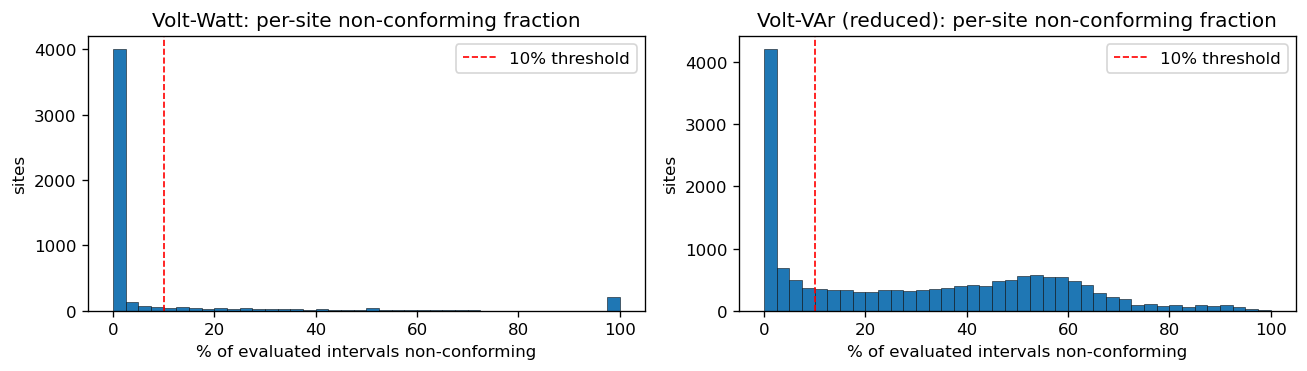

In [46]:
# Distribution of non-conforming fraction across sites
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), dpi=120)
for ax, (name, d) in zip(axes, [("Volt-Watt", vw_sites), ("Volt-VAr (reduced)", vvar_sites)]):
    ax.hist(d["nonconf_frac"].clip(0, 1)*100, bins=40, edgecolor="k", linewidth=0.3)
    ax.axvline(AS4777["SITE_CONF_THRESH"]*100, color="red", ls="--", lw=1,
               label=f"{AS4777['SITE_CONF_THRESH']*100:.0f}% threshold")
    ax.set_title(f"{name}: per-site non-conforming fraction")
    ax.set_xlabel("% of evaluated intervals non-conforming"); ax.set_ylabel("sites")
    ax.legend()
plt.tight_layout(); plt.show()

### 2.1. Volt-VAr non-conformance breakdown by failure mode

The five categories partition *how* a site fails Volt-VAr. 
- `inactive` is the classic fixed-power-factor inverter that skips Volt-VAr entirely.
- `adverse` is reactive power in the wrong direction. 
- `minor_deviation` and `major_surplus` are **excluded** from the reduced headline

In [47]:
# Labelled by Q_impact BAND (the table's own column names are swapped for the two middle bands).
vvar_breakdown = aq("""
    SELECT
        SUM(Q_adverse_count)         AS adverse__lt_m010,        -- wrong direction
        SUM(Q_inactive_count)        AS inactive__m010_to_010,   -- no response
        SUM(Q_minor_deviation_count) AS shortfall__010_to_090,   -- col 'Q_minor_deviation'; notes 'major deficit'
        SUM(Q_major_deficit_count)   AS nearmiss__090_to_110,    -- col 'Q_major_deficit'; notes 'minor deviation'
        SUM(Q_major_surplus_count)   AS surplus__gt_110,         -- over-response
        SUM(total_count)             AS total_evaluated
    FROM conformance_voltvar
    WHERE day_night = 'day'
""", database=SAI).T.rename(columns={0: "interval_count"})
vvar_breakdown["pct_of_evaluated"] = (
    vvar_breakdown["interval_count"] / vvar_breakdown.loc["total_evaluated", "interval_count"] * 100
).round(2)
vvar_breakdown

,interval_count,pct_of_evaluated
adverse__lt_m010,103375793,9.44
inactive__m010_to_010,186038056,16.98
shortfall__010_to_090,35926623,3.28
nearmiss__090_to_110,18864364,1.72
surplus__gt_110,73222896,6.68
total_evaluated,1095440815,100.0


### 2.2. Curtailment energy

- `curtailment_*_sum` columns are sums of per-interval kW shortfalls vs the GHI counterfactual.
- Multiply by the interval length (5/60 h) to get **kWh**. 
- Volt-VAr curtailment is the active power sacrificed to make reactive headroom.
- Volt-Watt-GHI curtailment is the energy backed off because voltage drove the Volt-Watt ramp.

In [48]:
def curtailment_energy(table, sum_col, count_col, gen_col=None, day_only=False, year_filter=None):
    conds = []
    if day_only:    conds.append("day_night = 'day'")
    if year_filter: conds.append(f"year = {year_filter}")
    where = ("WHERE " + " AND ".join(conds)) if conds else ""
    gen_sel = f"SUM({gen_col}) AS gen_kw_sum," if gen_col else ""
    df = aq(f"""
        SELECT site_id,
               {gen_sel}
               SUM({sum_col})   AS curt_kw_sum,
               SUM({count_col}) AS curt_intervals
        FROM {table} {where}
        GROUP BY site_id
    """, database=SAI)
    df["curt_kwh"] = df["curt_kw_sum"] * AS4777["INTERVAL_H"]
    msg = f"{table:26s}  fleet curtailed = {df['curt_kwh'].sum():,.0f} kWh across {len(df):,} sites"
    if gen_col:
        df["gen_kwh"] = df["gen_kw_sum"] * AS4777["INTERVAL_H"]
        # % curtailed vs uncurtailed (actual + curtailed) generation in eligible conditions
        denom = df["gen_kwh"].sum() + df["curt_kwh"].sum()
        if denom > 0:
            msg += f"  | {df['curt_kwh'].sum()/denom*100:.2f}% of eligible generation"
    print(msg)
    return df.sort_values("curt_kwh", ascending=False)

# V-Watt-GHI / curtailment exist for 2024 ONLY (NCI irradiance coverage Jan-Dec 2024).
# conformance_voltwattghi carries P_kW_sum (generation in eligible conditions) -> % curtailment.
curt_vw   = curtailment_energy("conformance_voltwattghi", "curtailment_voltwattghi_sum",
                               "curtailment_voltwattghi_count", gen_col="P_kW_sum", year_filter=2024)
curt_vvar = curtailment_energy("conformance_voltvar", "curtailment_voltvar_sum",
                               "curtailment_voltvar_count", gen_col="P_kW_sum",
                               day_only=True, year_filter=2024)
curt_vw.head(10)

conformance_voltwattghi     fleet curtailed = 5,345 kWh across 3,650 sites  | 0.38% of eligible generation
conformance_voltvar         fleet curtailed = 161 kWh across 14,595 sites  | 0.00% of eligible generation


,site_id,gen_kw_sum,curt_kw_sum,curt_intervals,curt_kwh,gen_kwh
975,449516314,505490.439454,7300.458527,824,608.371544,42124.203288
247,1302917070,76106.574766,2055.711917,742,171.309326,6342.214564
2114,465008538,152872.460182,1857.782343,955,154.815195,12739.371682
1850,755163749,130195.057113,1526.863660,653,127.238638,10849.588093
372,1588083868,21436.174371,1461.859829,691,121.821652,1786.347864
2051,1800975821,22252.011923,1345.089782,633,112.090815,1854.334327
97,1973437094,136278.138195,1166.520066,555,97.210006,11356.511516
2948,221985833,24118.005098,1069.424284,328,89.118690,2009.833758
2368,285085090,44151.387810,967.114054,537,80.592838,3679.282317
12,1559806445,98925.521046,964.776395,513,80.398033,8243.793420


### 2.3. Combined fleet summary table

In [49]:
summary = pd.DataFrame([
    {"mechanism": "Volt-Watt",           "n_sites": len(vw_sites),
     "pct_conformant": vw_sites["conformant"].mean()*100},
    {"mechanism": "Volt-VAr (reduced)",  "n_sites": len(vvar_sites),
     "pct_conformant": vvar_sites["conformant"].mean()*100},
    {"mechanism": "Sustained-op (258V)", "n_sites": len(sustop_sites),
     "pct_conformant": sustop_sites["conformant"].mean()*100},
    {"mechanism": "Anti-island (265V)",  "n_sites": len(ai_sites),
     "pct_conformant": ai_sites["conformant"].mean()*100},
]).round(1)
summary

,mechanism,n_sites,pct_conformant
0,Volt-Watt,5021,84.6
1,Volt-VAr (reduced),16148,35.7
2,Sustained-op (258V),294,26.9
3,Anti-island (265V),50,70.0


### 2.4. Report-aligned metrics (milestone figures)

The milestone report does **not** headline the 10% rule for Volt-Watt. Its V-Watt figures are:
1.  **% of eligible sites showing *any* non-conformance**, and
2.  **capacity-and-timestamp-normalised non-conformance** 
* mean per-interval excess as a fraction of nameplate, over eligible V>=253 intervals, broken down by :
    * state, 
    * DNSP, 
    * OEM,
    * install year. 

Curtailment is reported as **% of eligible-condition generation** (headline: V-Watt curtailment < 0.6%).

In [104]:
###########################################
# 2.4a  Per-site Volt-Watt report metrics #
###########################################
#-----(GHI-filtered, 2024 only)-------#

# Pulls all three sub-metrics the report uses.
#   (a) nc_count       : total 5-min NC instances per site
#   (b) nc_mwh         : cumulative NC energy (MWh) = nc_sum_kw * 5/60 / 1000
#   (c) norm_nc_wh_kw  : normalised NC = Wh excess / kW-nameplate / eligible interval
#                        = nc_sum_kw * (5/60) * 1000 / (total_count * ac_capacity_kw)
#
# NOTE: conformance_voltwatt already filters to V >= 253 intervals only, so total_count is the eligible denominator. No extra filter needed.

# NOTE: [!! IMPORTANT !!] The milestone report 3 (section 2) uses the *conformance_voltwattghi* database to generate the results presented in the volt-watt section.
#   - it excludes low-irradiance timestamps where reduced power could be cloud cover
#   - it is the table used for curtailment (consistent denominator)
#   - it matches the report's Figure 8/9 methodology (2024, GHI-eligible only)
#
# Column name differences vs conformance_voltwatt:
#   nonconformance_voltwattghi_sum   (not nonconformance_voltwatt_sum)
#   nonconformance_voltwattghi_count (not nonconformance_voltwatt_count)

vw_report = aq("""
    SELECT site_id,
           SUM(nonconformance_voltwattghi_sum)   AS nc_sum_kw,
           SUM(nonconformance_voltwattghi_count) AS nc_count,
           SUM(P_kW_sum)                         AS gen_sum_kw,
           SUM(total_count)                      AS total_count
    FROM conformance_voltwattghi
    WHERE year = 2024
    GROUP BY site_id
""", database=SAI)

# join nameplate capacity from meta
vw_report = vw_report.merge(
    aq("""SELECT DISTINCT site_id, max(ac_capacity_kw) AS ac_capacity_kw
          FROM meta_up23c WHERE is_pv=True GROUP BY site_id""", database=SAI),
    on="site_id", how="left"
)

INTERVAL_H = AS4777["INTERVAL_H"]   # 5/60

# (a) flag: any NC at all
vw_report["any_nonconf"] = vw_report["nc_count"] > 0

# (b) cumulative NC energy in MWh
vw_report["nc_mwh"] = vw_report["nc_sum_kw"] * INTERVAL_H / 1000

# (c) normalised NC: Wh excess per kW-nameplate per eligible interval
vw_report["norm_nc_wh_kw"] = (
    vw_report["nc_sum_kw"] * INTERVAL_H * 1000
    / (vw_report["total_count"] * vw_report["ac_capacity_kw"])
)

# keep old alias so nothing downstream breaks
vw_report["norm_nonconf"] = vw_report["norm_nc_wh_kw"]

print(f"Volt-Watt GHI eligible sites (2024):              {len(vw_report):,}")
print(f"  % with ANY non-conformance:                     {vw_report['any_nonconf'].mean()*100:.1f}%")
print(f"  Total fleet NC energy:                          {vw_report['nc_mwh'].sum():,.1f} MWh")
print(f"  Fleet mean normalised NC (Wh/kW/interval):      {vw_report['norm_nc_wh_kw'].mean():.4f}")
print(f"  Total eligible generation:                      {(vw_report['gen_sum_kw'] * INTERVAL_H / 1000).sum():,.1f} MWh")

Volt-Watt GHI eligible sites (2024):              3,650
  % with ANY non-conformance:                     24.9%
  Total fleet NC energy:                          75.4 MWh
  Fleet mean normalised NC (Wh/kW/interval):      0.7056
  Total eligible generation:                      1,412.0 MWh


In [105]:
# ── Derive the 10%-rule conformance flag on vw_report ────────────────────────
# A site is non-conformant if NC intervals >= 10% of eligible (V>=253) intervals.
# This matches the colleague's definition used in site_conformance().
# NOTE: vw_report is sourced from conformance_voltwattghi (GHI-filtered, 2024),
#       so total_count here = eligible GHI-filtered timestamps, not all V>=253.

CONF_THRESH = AS4777["SITE_CONF_THRESH"]   # 0.10

vw_report["nonconf_frac"]  = vw_report["nc_count"] / vw_report["total_count"]
vw_report["nonconf_site"]  = vw_report["nonconf_frac"] >= CONF_THRESH   # True = non-conformant
vw_report["conform_site"]  = ~vw_report["nonconf_site"]                 # True = conformant

# quick sanity check
n_total   = len(vw_report)
n_nonconf = vw_report["nonconf_site"].sum()
print(f"GHI-eligible sites:          {n_total:,}")
print(f"Non-conformant (>=10% rule): {n_nonconf:,}  ({n_nonconf/n_total*100:.1f}%)")
print(f"Conformant    (<10% rule):   {n_total-n_nonconf:,}  ({(n_total-n_nonconf)/n_total*100:.1f}%)")
print()
print(f"For comparison — 'any NC' rate: {vw_report['any_nonconf'].mean()*100:.1f}%")
print(f"The difference shows how many sites have occasional NC but below the 10% threshold.")

GHI-eligible sites:          3,650
Non-conformant (>=10% rule): 538  (14.7%)
Conformant    (<10% rule):   3,112  (85.3%)

For comparison — 'any NC' rate: 24.9%
The difference shows how many sites have occasional NC but below the 10% threshold.


In [106]:
##########################
# 2.4b  Breakdown helper #
##########################

META = aq("""
    SELECT DISTINCT site_id,
           state,
           dnsp_name             AS dnsp,
           manufacturer          AS oem,
           year(pv_install_date) AS install_year
    FROM meta_up23c WHERE is_pv = True
""", database=SAI)


def vw_breakdown(site_df, by, min_sites=1):
    d = site_df.merge(META, on="site_id", how="left")
    d = d.dropna(subset=[by] if isinstance(by, str) else by)
    g = (
        d.groupby(by, dropna=True)
         .agg(
             n_sites            = ("site_id",       "nunique"),
             # 10%-rule: % of sites where NC intervals >= 10% of eligible intervals
             pct_nonconf_10pct  = ("nonconf_site",  lambda s: s.mean() * 100),
             # 'any NC' rate kept for reference
             pct_any_nonconf    = ("any_nonconf",   lambda s: s.mean() * 100),
             total_nc_instances = ("nc_count",      "sum"),
             total_nc_mwh       = ("nc_mwh",        "sum"),
             mean_norm_nc_wh_kw = ("norm_nc_wh_kw", "mean"),
         )
         .reset_index()
    )
    g = g[g["n_sites"] >= min_sites].sort_values("pct_nonconf_10pct", ascending=False)
    for col in ("total_nc_instances", "total_nc_mwh",
                "mean_norm_nc_wh_kw", "pct_any_nonconf", "pct_nonconf_10pct"):
        g[col] = pd.to_numeric(g[col], errors="coerce").fillna(0).astype(float)
    return g.round({"pct_nonconf_10pct": 1, "pct_any_nonconf": 1,
                    "total_nc_mwh": 2, "mean_norm_nc_wh_kw": 4})




def plot_vw_breakdown(df, by_label, top_n=None, figsize=(13, 3.5)):
    """
    Three-panel horizontal bar chart:
      a) total NC instances (count of 5-min timestamps)
      b) cumulative NC energy (MWh)
      c) normalised NC (Wh / kW-nameplate / eligible interval)
    """
    d = df.copy()
    if top_n:
        d = d.nlargest(top_n, "mean_norm_nc_wh_kw")
    d = d.sort_values("mean_norm_nc_wh_kw", ascending=True)

    # ensure labels are clean strings with no NaN
    d[by_label] = d[by_label].astype(str).str.replace("nan", "Unknown", regex=False)
    labels = d[by_label].tolist()

    C = ["#1565c0", "#2e7d32", "#c62828"]
    fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=130)
    fig.suptitle(f"Volt-Watt non-conformance by {by_label}",
                 fontsize=10, fontweight="bold", y=1.01)

    specs = [
        ("total_nc_instances", "NC instances\n(5-min timestamps)", "a) Total NC instances"),
        ("total_nc_mwh",       "MWh",                              "b) Cumulative NC energy"),
        ("mean_norm_nc_wh_kw", "Wh / kW-nameplate / interval",     "c) Normalised NC"),
    ]
    for ax, (col, xlabel, title), colour in zip(axes, specs, C):
        values = d[col].values.astype(float)           # guaranteed float array → no type ambiguity
        ax.barh(range(len(labels)), values, color=colour, alpha=0.85)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_title(title, fontsize=8.5, fontweight="bold")
        ax.tick_params(labelsize=8)
        ax.grid(axis="x", color="#e8e8e8", lw=0.6)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()


by_state = vw_breakdown(vw_report, "state",        min_sites=1)
by_dnsp  = vw_breakdown(vw_report, "dnsp",         min_sites=1)
by_oem   = vw_breakdown(vw_report, "oem",          min_sites=100)
by_year  = vw_breakdown(vw_report, "install_year", min_sites=1)

print("=== By state ===");        display(by_state)
print("=== By DNSP ===");         display(by_dnsp)
print("=== By OEM (≥100) ===");   display(by_oem)
print("=== By install year ==="); display(by_year)

=== By state ===


,state,n_sites,pct_nonconf_10pct,pct_any_nonconf,total_nc_instances,total_nc_mwh,mean_norm_nc_wh_kw
3,QLD,1391,22.9,31.5,357659.0,57.69,1.2474
4,SA,265,16.7,26.4,20328.0,2.17,0.5947
7,WA,113,14.9,18.6,11521.0,1.14,0.3424
2,NT,65,14.3,24.6,2117.0,0.06,0.2202
1,NSW,1375,12.4,22.5,118506.0,14.13,0.4092
0,ACT,70,10.2,18.6,3524.0,0.17,0.3130
6,VIC,334,4.6,11.1,1310.0,0.08,0.1373
5,TAS,37,3.2,13.5,212.0,0.01,0.1159


=== By DNSP ===


,dnsp,n_sites,pct_nonconf_10pct,pct_any_nonconf,total_nc_instances,total_nc_mwh,mean_norm_nc_wh_kw
6,Ergon,1013,26.1,35.9,347864.0,57.76,1.5330
13,Western Power,16,23.1,18.8,582.0,0.02,0.5255
11,SAPN,257,16.7,25.7,19680.0,2.14,0.5841
7,Essential,492,15.6,28.0,62614.0,7.98,0.4714
5,Energex,351,14.6,19.9,14364.0,0.77,0.4742
9,Power and Water Corporation,10,11.1,10.0,33.0,0.00,0.2307
4,Endeavour,337,10.7,17.8,12743.0,1.30,0.2857
1,Ausgrid,577,10.4,20.5,44937.0,4.99,0.4322
0,Actewagl,70,10.2,18.6,3524.0,0.17,0.3130
10,Powercor,98,6.8,12.2,513.0,0.02,0.1441


=== By OEM (≥100) ===


,oem,n_sites,pct_nonconf_10pct,pct_any_nonconf,total_nc_instances,total_nc_mwh,mean_norm_nc_wh_kw
10,GoodWe,658,24.5,34.0,219060.0,43.43,1.4724
6,Fronius,699,20.3,30.8,90206.0,7.64,0.7202
26,Sungrow,673,15.0,24.2,115996.0,13.49,0.4775
8,Generic Inverter,870,14.7,20.5,71622.0,9.45,0.7284
18,SMA,281,7.1,16.0,6014.0,0.34,0.2705
23,SolaX,150,5.2,14.0,2376.0,0.11,0.1198


=== By install year ===


,install_year,n_sites,pct_nonconf_10pct,pct_any_nonconf,total_nc_instances,total_nc_mwh,mean_norm_nc_wh_kw
2,2011,2,50.0,50.0,2.0,0.00,0.3881
1,2010,3,33.3,33.3,1143.0,0.11,3.2579
13,2022,566,21.5,27.7,148736.0,29.66,1.1959
11,2020,758,18.2,28.4,115478.0,13.61,0.6751
12,2021,745,18.0,29.4,148488.0,22.62,0.8395
9,2018,119,17.1,27.7,11330.0,1.89,0.7808
8,2017,48,15.9,27.1,2753.0,0.08,0.3974
6,2015,14,15.4,50.0,430.0,0.02,0.5484
7,2016,38,13.9,28.9,416.0,0.02,0.1976
10,2019,417,13.5,19.4,18385.0,1.23,0.4303


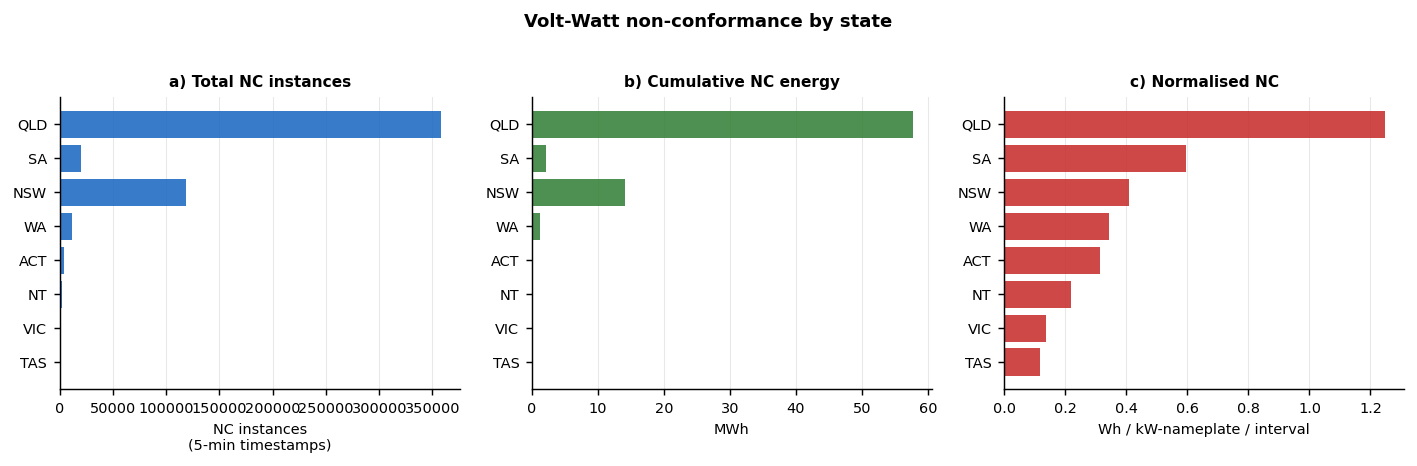

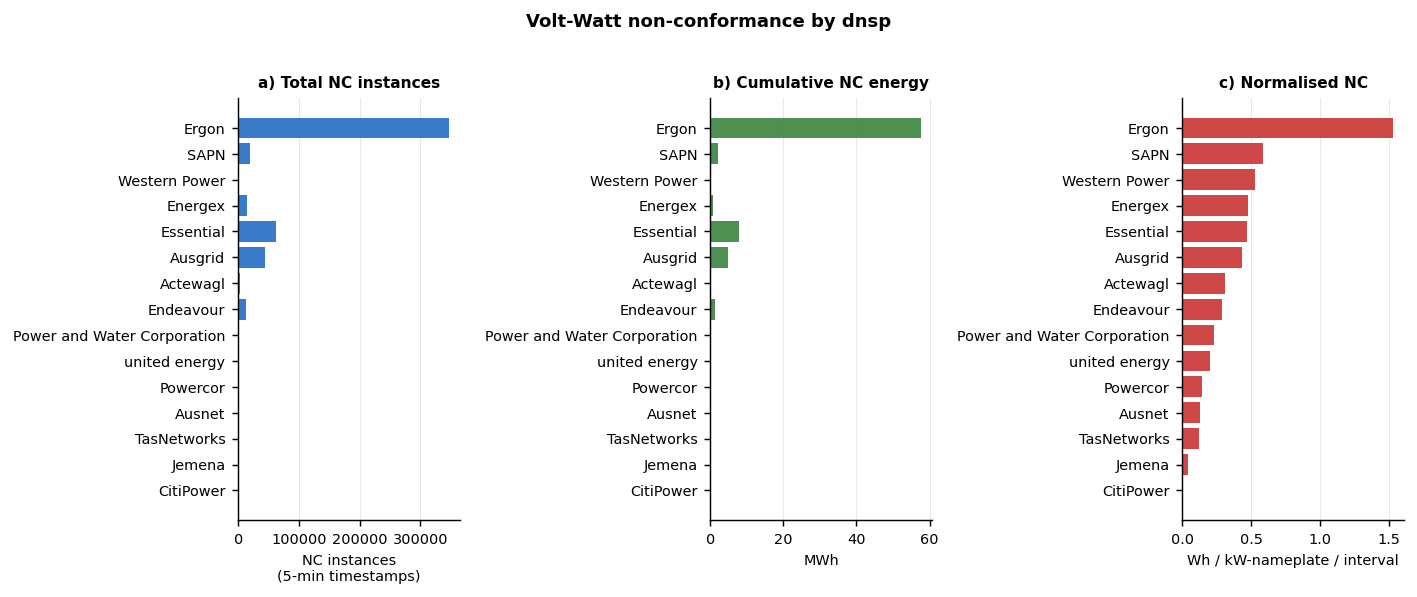

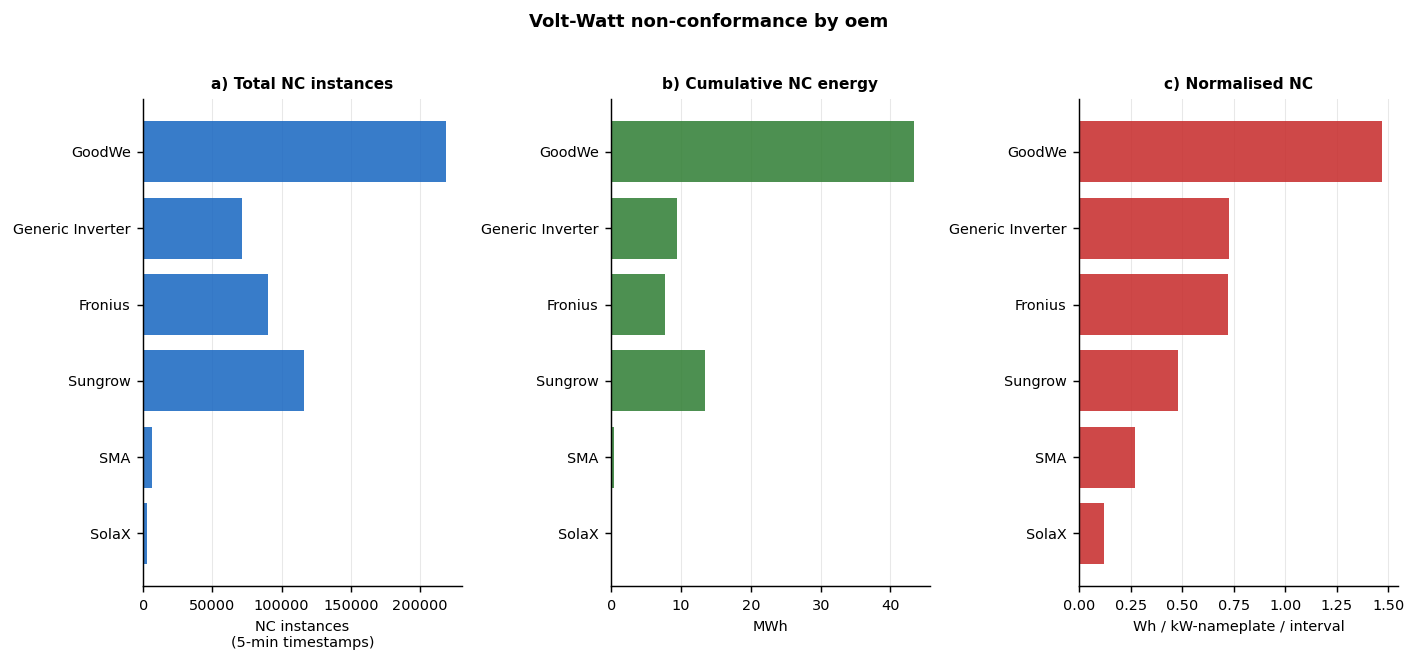

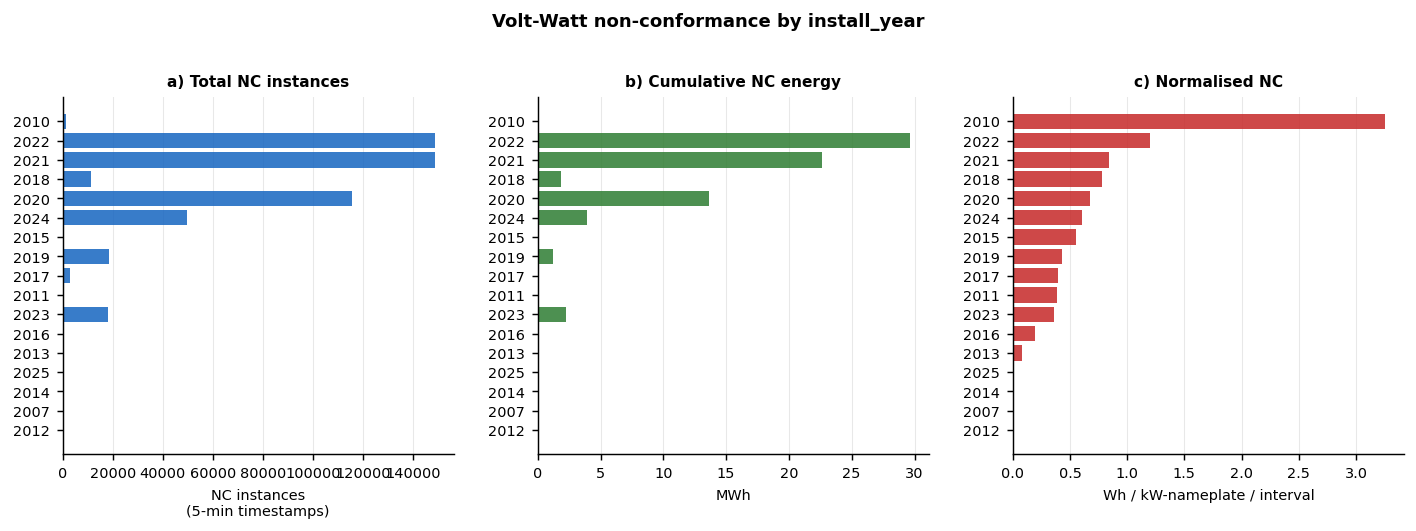

In [107]:
# 2.4c  Report-style bar charts

plot_vw_breakdown(by_state, "state",        figsize=(11, 3.5))
plot_vw_breakdown(by_dnsp,  "dnsp",         figsize=(11, 4.5))
plot_vw_breakdown(by_oem,   "oem",  top_n=10, figsize=(11, 5))
plot_vw_breakdown(by_year,  "install_year", figsize=(11, 4))

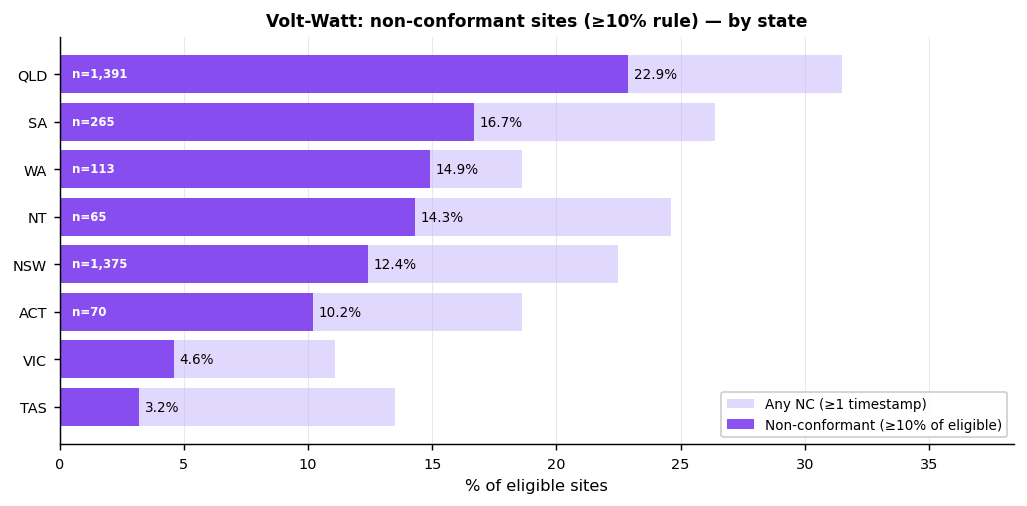

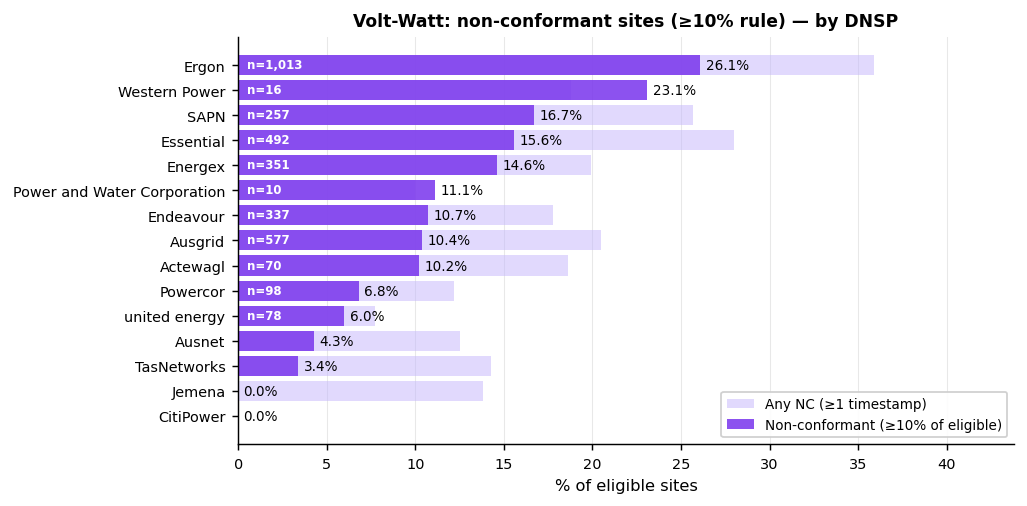

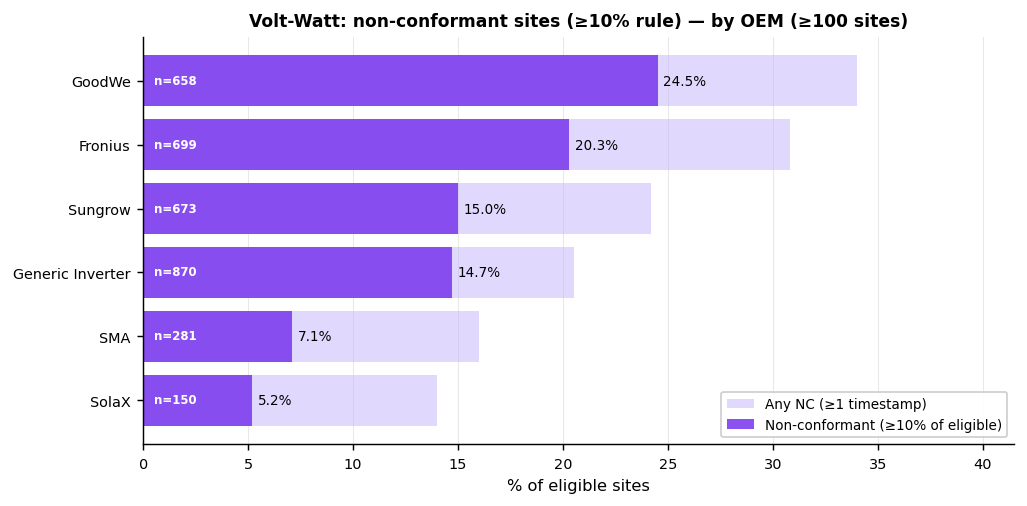

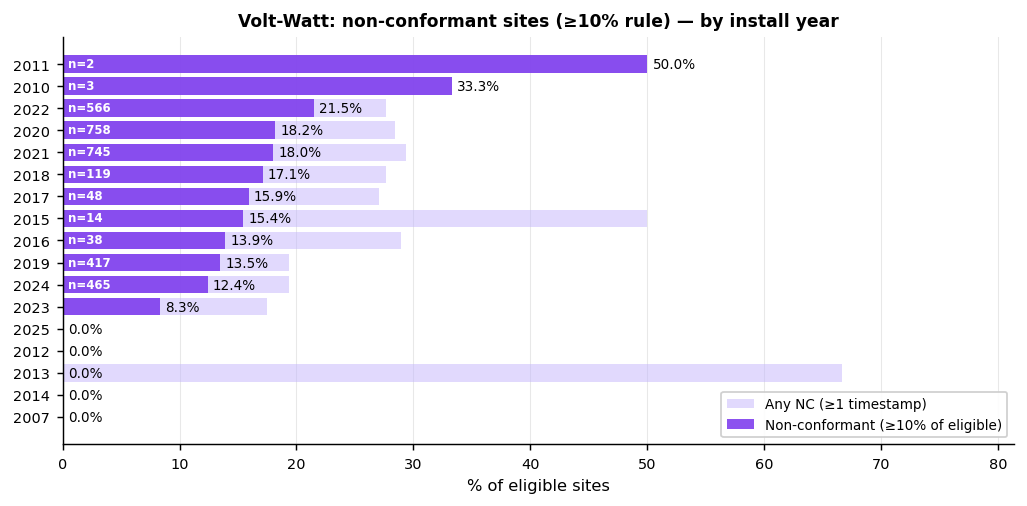

In [108]:
# ── 2.4d  % of non-conformant sites per group (10%-rule, Figure 12a equivalent)
def plot_pct_any_nonconf(df, by_label, title_suffix="", figsize=(8, 4)):
    d = df.copy()
    d = d.dropna(subset=[by_label])
    d[by_label] = d[by_label].astype(str).str.replace("nan", "Unknown", regex=False)
    d = d.sort_values("pct_nonconf_10pct", ascending=True)

    labels = d[by_label].tolist()
    vals_10pct  = d["pct_nonconf_10pct"].values.astype(float)
    vals_any    = d["pct_any_nonconf"].values.astype(float)

    fig, ax = plt.subplots(figsize=figsize, dpi=130)

    # ghost bar: 'any NC' rate (lighter, behind)
    ax.barh(range(len(labels)), vals_any,
            color="#c4b5fd", alpha=0.50, label="Any NC (≥1 timestamp)")

    # main bar: 10%-rule non-conformance rate
    bars = ax.barh(range(len(labels)), vals_10pct,
                   color="#7c3aed", alpha=0.88, label="Non-conformant (≥10% of eligible)")

    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=7.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("% of eligible sites", fontsize=9)
    ax.set_title(
        f"Volt-Watt: non-conformant sites (≥10% rule){title_suffix}",
        fontsize=9.5, fontweight="bold",
    )
    xlim = vals_any.max() * 1.22 if vals_any.max() > 0 else 1
    ax.set_xlim(0, xlim)
    ax.grid(axis="x", color="#e8e8e8", lw=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7.5, loc="lower right", framealpha=0.9)

    # n_sites label inside each bar (only if bar is wide enough to fit)
    for i, (_, row) in enumerate(d.iterrows()):
        label_txt = f"n={int(row['n_sites']):,}"
        if vals_10pct[i] > xlim * 0.12:   # only annotate if bar has room
            ax.text(0.5, i, label_txt, va="center",
                    fontsize=6.5, color="white", fontweight="bold")

    plt.tight_layout()
    plt.show()


plot_pct_any_nonconf(by_state, "state",        " — by state")
plot_pct_any_nonconf(by_dnsp,  "dnsp",         " — by DNSP")
plot_pct_any_nonconf(by_oem,   "oem",          " — by OEM (≥100 sites)")
plot_pct_any_nonconf(by_year,  "install_year", " — by install year")

### 2.5. Restrict to a single-inverter cohort

The full-fleet Iceberg tables include multi-inverter and commercial sites. 
To approach the report's **16,148** cohort, restrict to single-inverter sites with a validated nameplate.
This is a *stub*. The authoritative cohort lives in the Hive `meta_single_inverters*` tables.

adapt the filter once you confirm its exact definition.

In [52]:
# Cohort per the colleague's notes: "1 inverter, up to 3 circuits", valid nameplate.
# meta_up23c carries inverter_count; PV-circuit count separates single-phase (1) from three-phase (3).
cohort = aq("""
    SELECT site_id
    FROM (
        SELECT site_id,
               max(inverter_count) AS inverter_count,
               count(*)            AS n_pv_circuits,
               max(ac_capacity_kw) AS ac_capacity_kw
        FROM meta_up23c
        WHERE is_pv = True
        GROUP BY site_id
    )
    WHERE inverter_count = 1 AND n_pv_circuits <= 3 AND ac_capacity_kw IS NOT NULL
""", database=SAI)
print("single-inverter (<=3 PV circuits, valid capacity) sites:", cohort["site_id"].nunique())

# Re-run any mechanism on the cohort by inner-joining vw_sites etc. on site_id:
vw_cohort = vw_sites.merge(cohort, on="site_id", how="inner")
print(f"Volt-Watt on cohort: {len(vw_cohort)} sites, "
      f"{vw_cohort['conformant'].mean()*100:.1f}% conformant")

single-inverter (<=3 PV circuits, valid capacity) sites: 16148
Volt-Watt on cohort: 5021 sites, 84.6% conformant


## 3. Single-site replicatio

Per-interval Volt-Watt and Volt-VAr logic in plain Athena SQL (no `system.bucket`, no Trino) for **one site-month**.

In [53]:
# Example non-conformant:
SITE_ID = 1400281710   # <-- 

#Example conformant:
SITE_ID = 933373036   # <-- 

# Other
SITE_ID = 1302917070

YEAR, MONTH = 2024, 1

In [54]:
# 3.1 Volt-Watt, interval level, reproduced from raw `ts`.
vw_tol = AS4777["TOL_FRAC"]; v1, v2, p2 = AS4777["VW"]["V1"], AS4777["VW"]["V2"], AS4777["VW"]["P2"]
vw_check = aq(f"""
    WITH data AS (
        SELECT site_id, t_stamp,
               sum(power*circuit_polarity/1000) AS P_kW,
               avg(voltage)                     AS V,
               max(ac_capacity_kw)              AS ac_capacity_kw
        FROM ts
        JOIN (SELECT DISTINCT site_id, circuit_id, circuit_polarity, ac_capacity_kw
              FROM meta_up23c WHERE is_pv = True) m USING (circuit_id)
        WHERE year={YEAR} AND month={MONTH} AND is_pv=True
          AND voltage > 0 AND voltage < 300 AND site_id = {SITE_ID}
        GROUP BY site_id, t_stamp
        HAVING avg(voltage) > {v1}
    ),
    pq AS (
        SELECT *,
               (CASE WHEN V < {v1} THEN ac_capacity_kw
                     WHEN V > {v2} THEN {p2}*ac_capacity_kw
                     ELSE (ac_capacity_kw - {p2}*ac_capacity_kw)/({v1}-{v2})*(V-{v2}) + {p2}*ac_capacity_kw
                END) + {vw_tol}*ac_capacity_kw AS max_P_volt_watt
        FROM data
    )
    SELECT day(t_stamp) AS day,
           sum(greatest(0, P_kW - max_P_volt_watt))                    AS nonconf_sum,
           sum(CASE WHEN P_kW - max_P_volt_watt > 0 THEN 1 ELSE 0 END) AS nonconf_count,
           count(*)                                                    AS total_count
    FROM pq GROUP BY day(t_stamp) ORDER BY day
""", database=SAI)

vw_table = aq(f"""
    SELECT day,
           nonconformance_voltwatt_sum   AS nonconf_sum,
           nonconformance_voltwatt_count AS nonconf_count,
           total_count
    FROM conformance_voltwatt
    WHERE site_id={SITE_ID} AND year={YEAR} AND month={MONTH}
    ORDER BY day
""", database=SAI)

print("Reproduced from raw ts:"); display(vw_check.head())
print("Stored in conformance_voltwatt:"); display(vw_table.head())
# They should match day-by-day (small float diffs are fine).

Reproduced from raw ts:


,day,nonconf_sum,nonconf_count,total_count
0,1,35.419748,21,40
1,2,9.029726,6,18
2,3,41.761417,20,23
3,4,51.509733,21,46
4,5,80.474750,31,56


Stored in conformance_voltwatt:


,day,nonconf_sum,nonconf_count,total_count
0,1,35.419748,21,40
1,2,9.029726,6,18
2,3,41.761417,20,23
3,4,51.509733,21,46
4,5,80.474750,31,56


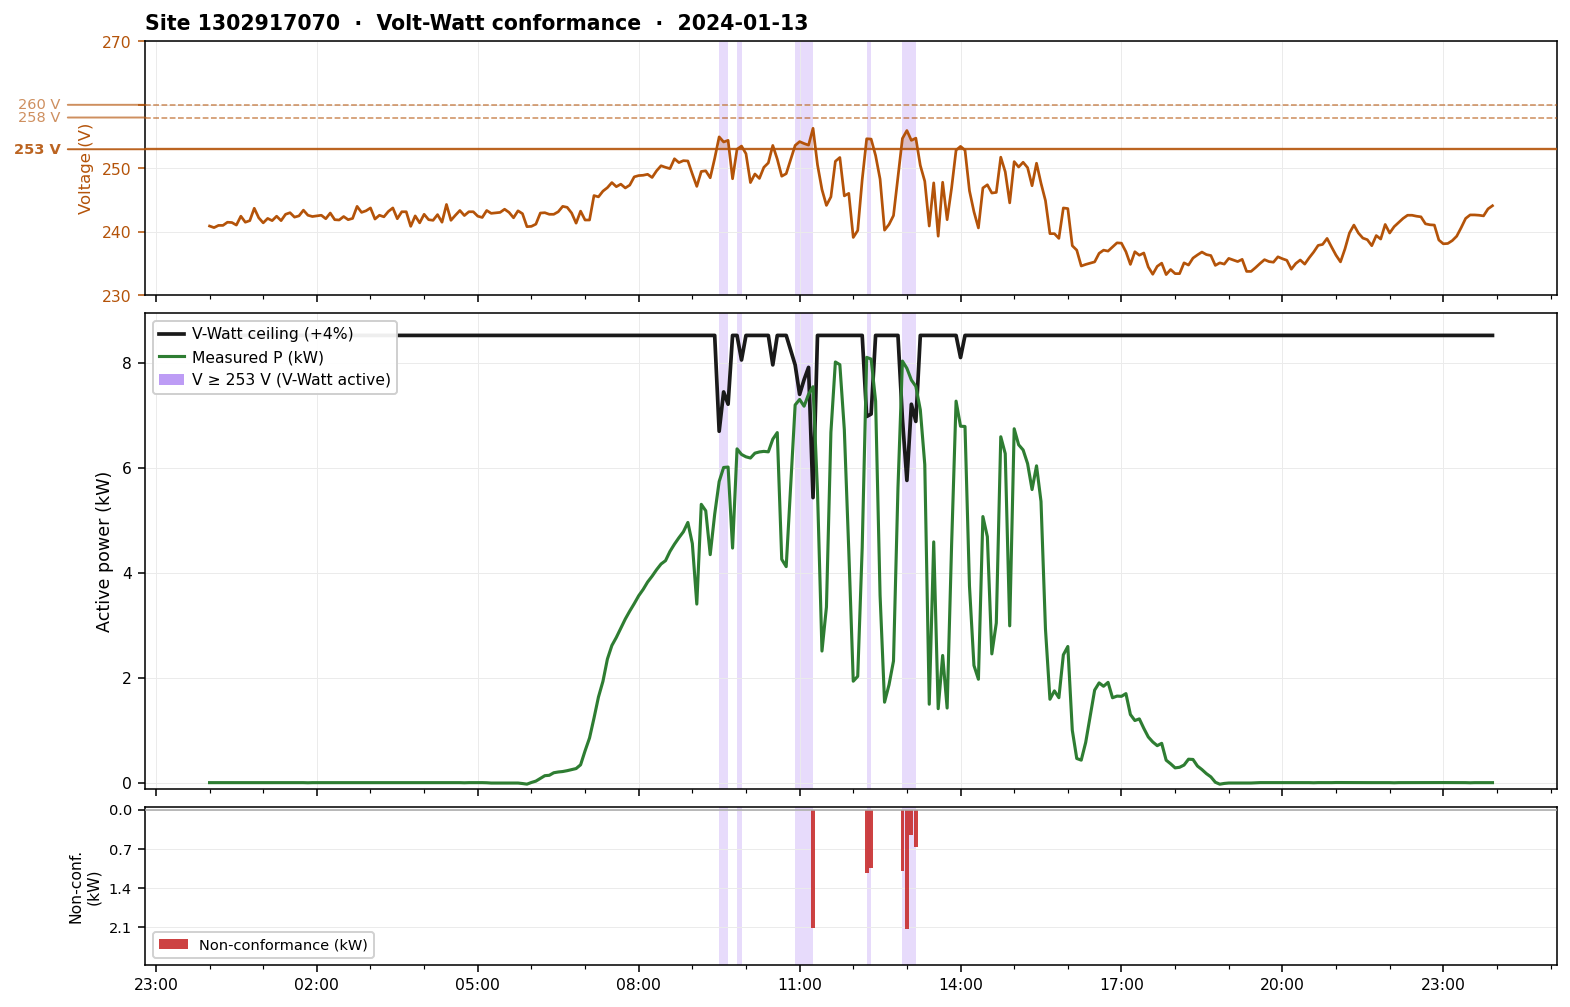

In [55]:
# ── Volt-Watt conformance: 3-panel plot ──────────────────────────────────────
# Requires: ts_site already pulled (P_kW, V, ac_capacity_kw, t_local)
#           get_max_P() and AS4777 already defined above
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── date window ───────────────────────────────────────────────────────────────
start_date = "2024-01-13"
end_date   = "2024-01-14"

day = ts_site[
    (ts_site["t_local"] >= start_date) &
    (ts_site["t_local"] <  end_date)
].copy()

day["max_P_vw"] = day.apply(
    lambda r: get_max_P(r["V"], r["ac_capacity_kw"])
              + AS4777["TOL_FRAC"] * r["ac_capacity_kw"], axis=1)
day["nc_vw"] = np.maximum(0, day["P_kW"] - day["max_P_vw"])

# KEY: strip timezone so matplotlib fill_between renders correctly.
# t_local is a fixed UTC+10 offset, so tz_localize(None) removes the label
# without shifting values — H:M tick labels still read as local time.
day["t_plot"] = day["t_local"].dt.tz_localize(None)

# ── palette ───────────────────────────────────────────────────────────────────
C_POWER = "#2e7d32"   # green  – measured power
C_CEIL  = "#1a1a1a"   # near-black – V-Watt ceiling
C_VOLT  = "#b45309"   # warm amber-brown – voltage
C_NC    = "#c62828"   # red – non-conformance bars
C_GRID  = "#ebebeb"
C_SHADE = "#7c3aed"   # violet – V-Watt active zone

# ── voltage y-axis range: zoomed to show thresholds clearly ──────────────────
# 230–270 gives clear separation between 253/258/260 labels.
# Change to 200, 300 if you prefer to show the full nominal range.
V_LO, V_HI = 230, 270

# ── layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7.5), dpi=140)
fig.subplots_adjust(left=0.13, right=0.97, top=0.95, bottom=0.07)
gs    = fig.add_gridspec(3, 1, height_ratios=[1.6, 3, 1], hspace=0.06)
ax_v  = fig.add_subplot(gs[0])
ax    = fig.add_subplot(gs[1], sharex=ax_v)
ax_nc = fig.add_subplot(gs[2], sharex=ax_v)

# ── violet zone shading (must use tz-naive t_plot) ────────────────────────────
for _ax in (ax_v, ax, ax_nc):
    _ax.fill_between(
        day["t_plot"], 0, 1,
        where=day["V"] >= 253,
        transform=_ax.get_xaxis_transform(),
        color=C_SHADE, alpha=0.18, zorder=0, linewidth=0,
    )

# ═══════════════════════════════════════════════════════════════════
# PANEL 1 — Voltage
# ═══════════════════════════════════════════════════════════════════
ax_v.plot(day["t_plot"], day["V"], color=C_VOLT, lw=1.4, zorder=4)

# fill between voltage curve and 253 — shows exceedance magnitude
ax_v.fill_between(
    day["t_plot"], 253, day["V"],
    where=day["V"] >= 253,
    color=C_VOLT, alpha=0.22, zorder=2, linewidth=0,
)

# reference lines
V_REFS = [
    (253, "-",  1.2, 0.90, "bold"),
    (258, "--", 0.8, 0.65, "normal"),
    (260, "--", 0.8, 0.65, "normal"),
]
for v_ref, ls, lw, alpha, fw in V_REFS:
    ax_v.axhline(v_ref, color=C_VOLT, lw=lw, ls=ls, alpha=alpha, zorder=3)

ax_v.set_ylim(V_LO, V_HI)
# round-number ticks only; threshold values annotated separately
ax_v.set_yticks([230, 240, 250, 260, 270])
ax_v.set_yticklabels(["230", "240", "250", "", "270"])  # 260 suppressed — labelled as annotation
ax_v.set_ylabel("Voltage (V)", fontsize=8.5, color=C_VOLT)
ax_v.tick_params(axis="y", colors=C_VOLT, labelsize=8)
ax_v.grid(True, color=C_GRID, lw=0.5, zorder=0)
ax_v.set_facecolor("white")
plt.setp(ax_v.get_xticklabels(), visible=False)

# draw canvas so axis transforms are finalised before placing annotations
fig.canvas.draw()

# blended transform: x in axes-fraction space, y in data (voltage) space
blend = mtransforms.blended_transform_factory(ax_v.transAxes, ax_v.transData)

for v_ref, _, _, alpha, fw in V_REFS:
    # short horizontal connector from the label to the left spine
    ax_v.annotate(
        "",
        xy     =(0,      v_ref), xycoords=blend,
        xytext =(-0.055, v_ref), textcoords=blend,
        arrowprops=dict(arrowstyle="-", color=C_VOLT, lw=1.0,
                        alpha=alpha, shrinkA=0, shrinkB=0),
        zorder=7, clip_on=False,
    )
    # text label left of the connector
    ax_v.text(
        -0.06, v_ref,
        f"{v_ref} V",
        transform=blend,
        ha="right", va="center",
        fontsize=7.5, color=C_VOLT, fontweight=fw, alpha=alpha,
        clip_on=False,
    )

# ═══════════════════════════════════════════════════════════════════
# PANEL 2 — Active power vs V-Watt ceiling
# ═══════════════════════════════════════════════════════════════════
ax.plot(day["t_plot"], day["max_P_vw"], color=C_CEIL, lw=1.9, zorder=4)
ax.plot(day["t_plot"], day["P_kW"],     color=C_POWER, lw=1.6, zorder=5)

ax.set_ylabel("Active power (kW)", fontsize=9)
ax.tick_params(axis="y", labelsize=8)
ax.set_ylim(bottom=-0.12)
ax.grid(True, color=C_GRID, lw=0.5, zorder=0)
ax.set_facecolor("white")
plt.setp(ax.get_xticklabels(), visible=False)

ax.legend(
    handles=[
        Line2D([0],[0], color=C_CEIL,  lw=1.9, label="V-Watt ceiling (+4%)"),
        Line2D([0],[0], color=C_POWER, lw=1.6, label="Measured P (kW)"),
        Patch(facecolor=C_SHADE, edgecolor="none", alpha=0.50,
              label="V ≥ 253 V (V-Watt active)"),
    ],
    loc="upper left", fontsize=8, framealpha=0.93,
    edgecolor="#cccccc", handlelength=1.6, handletextpad=0.5,
)

# ═══════════════════════════════════════════════════════════════════
# PANEL 3 — Non-conformance bars (pointing downward from zero)
# ═══════════════════════════════════════════════════════════════════
bar_w  = pd.Timedelta(minutes=4.3)
nc_pos = day["nc_vw"] > 0

ax_nc.bar(
    day.loc[nc_pos, "t_plot"],
    -day.loc[nc_pos, "nc_vw"],
    width=bar_w, color=C_NC, alpha=0.88, zorder=3, linewidth=0,
)
ax_nc.axhline(0, color="#aaaaaa", lw=0.8, zorder=4)

nc_max    = day["nc_vw"].max() if nc_pos.any() else 0.5
tick_step = max(round(nc_max / 3, 1), 0.5)
nc_ticks  = np.arange(0, nc_max * 1.25, tick_step)
ax_nc.set_yticks(-nc_ticks)
ax_nc.set_yticklabels([f"{v:.1f}" for v in nc_ticks], fontsize=7.5)
ax_nc.set_ylim(-(nc_max * 1.30), 0.05)
ax_nc.set_ylabel("Non-conf.\n(kW)", fontsize=8, labelpad=4)
ax_nc.grid(True, color=C_GRID, lw=0.5, axis="y", zorder=0)
ax_nc.set_facecolor("white")
ax_nc.legend(
    [Patch(facecolor=C_NC, alpha=0.88, linewidth=0)],
    ["Non-conformance (kW)"],
    loc="lower left", fontsize=7.5, framealpha=0.9, edgecolor="#cccccc",
)

# ── shared x-axis ─────────────────────────────────────────────────────────────
ax_nc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_nc.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax_nc.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
ax_nc.tick_params(axis="x", which="major", labelsize=8, pad=3)
ax_nc.tick_params(axis="x", which="minor", length=2)

# ── title: attached to the top panel, flush left ──────────────────────────────
date_str = str(day["t_local"].dt.date.iloc[0])
ax_v.set_title(
    f"Site {SITE_ID}  ·  Volt-Watt conformance  ·  {date_str}",
    fontsize=10.5, fontweight="bold", pad=6, loc="left",
)

plt.show()

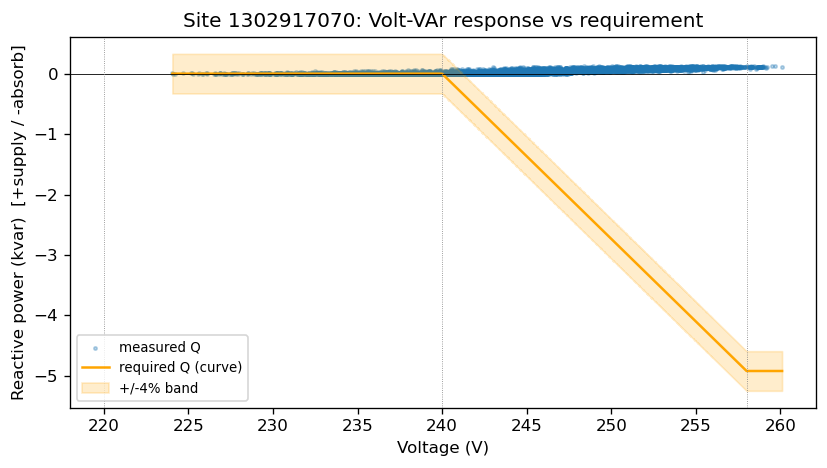

In [56]:
# 3.3 Volt-VAr interval level (P, Q, V, required band) for one site-month.
vv = AS4777["VVAR"]; tol = AS4777["TOL_FRAC"]
vvar_intervals = aq(f"""
    WITH data AS (
        SELECT site_id, t_stamp,
               sum(power*circuit_polarity/1000)              AS P_kW,
               sum(energy_reactive*circuit_polarity/1000*12) AS Q_kvar,
               avg(voltage)                                  AS V,
               max(ac_capacity_kw)                           AS ac_capacity_kw
        FROM ts
        JOIN (SELECT DISTINCT site_id, circuit_id, circuit_polarity, ac_capacity_kw
              FROM meta_up23c WHERE is_pv=True) m USING (circuit_id)
        WHERE year={YEAR} AND month={MONTH} AND is_pv=True
          AND voltage > 0 AND voltage < 300 AND site_id = {SITE_ID}
        GROUP BY site_id, t_stamp
    )
    SELECT t_stamp, P_kW, Q_kvar, V, ac_capacity_kw,
           CASE WHEN V < {vv['V1']} THEN {vv['Q1']}*ac_capacity_kw
                WHEN V < {vv['V2']} THEN ({vv['Q1']}*ac_capacity_kw)/({vv['V1']}-{vv['V2']})*(V-{vv['V2']})
                WHEN V <= {vv['V3']} THEN 0
                WHEN V < {vv['V4']} THEN -(0 - {vv['Q4']}*ac_capacity_kw)/({vv['V3']}-{vv['V4']})*(V-{vv['V4']}) - {vv['Q4']}*ac_capacity_kw
                ELSE -{vv['Q4']}*ac_capacity_kw END AS Q_voltvar
    FROM data ORDER BY t_stamp
""", database=SAI)
vvar_intervals["Q_req_max"] = vvar_intervals["Q_voltvar"] + tol*vvar_intervals["ac_capacity_kw"]
vvar_intervals["Q_req_min"] = vvar_intervals["Q_voltvar"] - tol*vvar_intervals["ac_capacity_kw"]

# Q vs V: measured reactive against the required band. If sign convention is correct,
# points at high V should sit in the negative (absorbing) band.
m = vvar_intervals
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.scatter(m["V"], m["Q_kvar"], s=4, alpha=0.3, label="measured Q")
order = m.sort_values("V")
ax.plot(order["V"], order["Q_voltvar"], color="orange", label="required Q (curve)")
ax.fill_between(order["V"], order["Q_req_min"], order["Q_req_max"], color="orange", alpha=0.2,
                label="+/-4% band")
ax.axhline(0, color="k", lw=0.5)
for vx in (220, 240, 258): ax.axvline(vx, color="grey", lw=0.5, ls=":")
ax.set_xlabel("Voltage (V)"); ax.set_ylabel("Reactive power (kvar)  [+supply / -absorb]")
ax.set_title(f"Site {SITE_ID}: Volt-VAr response vs requirement"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Sign-convention check.** In the plot above, at **high voltage** (V > 240) the measured
reactive power should swing **negative** (absorbing) toward the orange curve. If your
fleet's points instead go positive there, the raw `energy_reactive` sign is opposite to
what the pipeline assumes and every Volt-VAr result is mirrored — confirm with the
provider before trusting Volt-VAr magnitudes.

In [57]:
# 3.4 Reproduce the Volt-VAr classification for the single site, labelled by BAND.
# This lets you see directly which Q_impact band each table column corresponds to.
df = vvar_intervals.copy()
S = df["ac_capacity_kw"]
df["Q_req_max"] = df["Q_voltvar"] + AS4777["TOL_FRAC"]*S
df["Q_req_min"] = df["Q_voltvar"] - AS4777["TOL_FRAC"]*S

# Q_impact = signed |measured| / |nearer required bound|  (mirrors the builder)
def q_impact(r):
    a = abs(r["Q_kvar"]) / (abs(r["Q_req_max"]) + 1e-9)
    b = abs(r["Q_kvar"]) / (abs(r["Q_req_min"]) + 1e-9)
    if a <= b:
        bound, ratio = r["Q_req_max"], a
    else:
        bound, ratio = r["Q_req_min"], b
    if r["Q_req_max"] + r["Q_req_min"] == 0:
        return ratio
    return np.sign(bound) * np.sign(r["Q_kvar"]) * ratio
df["Q_impact"] = df.apply(q_impact, axis=1)

t = AS4777["QIMP"]
outside = (df["Q_kvar"] < df["Q_req_min"]) | (df["Q_kvar"] > df["Q_req_max"])
def band(imp):
    if imp < t["thr1"]:                 return "1_adverse (<-0.1)"
    if imp <= t["thr2"]:                return "2_inactive (-0.1..0.1)"
    if imp <  t["thr3"]:                return "3_shortfall (0.1..0.9)  [col=Q_minor_deviation]"
    if imp <= t["thr4"]:                return "4_nearmiss (0.9..1.1)   [col=Q_major_deficit]"
    return "5_surplus (>1.1)"
df["category"] = np.where(outside, df["Q_impact"].map(band), "0_conforming (in band)")
print(df["category"].value_counts().sort_index())

category
0_conforming (in band)    2827
1_adverse (<-0.1)            2
2_inactive (-0.1..0.1)    6083
Name: count, dtype: int64



In the overlap zone both responses act at once: the inverter must reserve apparent-power
headroom for the **required reactive** *and* obey the **Volt-Watt ramp**. The binding
active-power ceiling is the lower of the two. This is the concurrent-operation curve
(per clause 3.3.2.1) — the reference to overlay measured P/Q against.

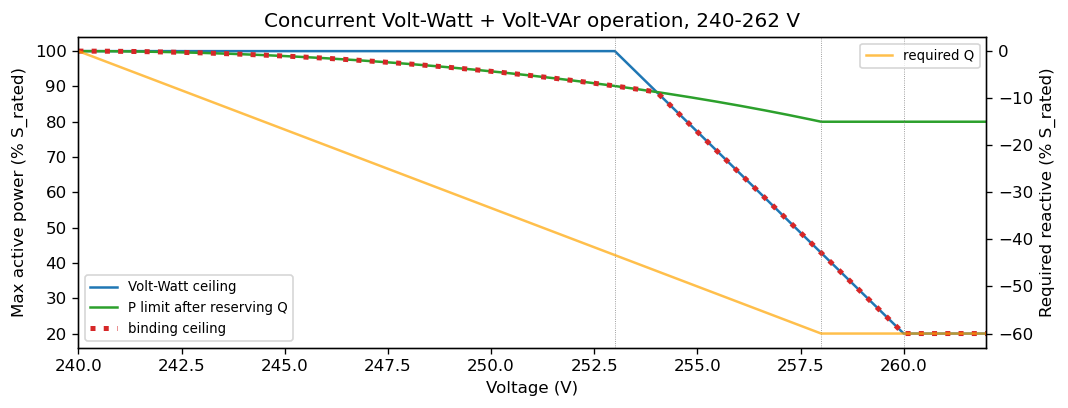

,V,P_voltwatt,Q_required,P_apparent_lim,P_binding
260,253.0,100.000000,-43.333333,90.123372,90.123372
300,255.0,77.142857,-50.000000,86.602540,77.142857
312,255.6,70.285714,-52.000000,85.416626,70.285714
320,256.0,65.714286,-53.333333,84.590517,65.714286
360,258.0,42.857143,-60.000000,80.000000,42.857143


In [58]:
S = 100.0
Vv = np.round(np.arange(240, 262.01, 0.05), 2)
ref = pd.DataFrame({"V": Vv})
ref["P_voltwatt"]     = ref["V"].map(lambda v: get_max_P(v, S))
ref["Q_required"]     = ref["V"].map(lambda v: get_voltvar_Q(v, S))
ref["P_apparent_lim"] = (S**2 - ref["Q_required"]**2).clip(lower=0)**0.5
ref["P_binding"]      = ref[["P_voltwatt", "P_apparent_lim"]].min(axis=1)

fig, ax = plt.subplots(figsize=(9, 3.5), dpi=120); ax2 = ax.twinx()
ax.plot(ref["V"], ref["P_voltwatt"],     color="tab:blue",  label="Volt-Watt ceiling")
ax.plot(ref["V"], ref["P_apparent_lim"], color="tab:green", label="P limit after reserving Q")
ax.plot(ref["V"], ref["P_binding"],      color="tab:red", lw=3, ls=":", label="binding ceiling")
ax2.plot(ref["V"], ref["Q_required"],    color="orange", alpha=0.7, label="required Q")
for vx in (253, 258, 260): ax.axvline(vx, color="grey", lw=0.5, ls=":")
ax.set_xlabel("Voltage (V)"); ax.set_ylabel("Max active power (% S_rated)")
ax2.set_ylabel("Required reactive (% S_rated)")
ax.legend(loc="lower left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
ax.set_title("Concurrent Volt-Watt + Volt-VAr operation, 240-262 V"); ax.margins(x=0)
plt.tight_layout(); plt.show()
ref[ref.V.isin([253, 255, 255.6, 256, 258])]

---
### Open items / things to confirm with live data
- **Reactive sign convention** — verify via the Q-vs-V plot in 3.3 before reporting Volt-VAr magnitudes.
- **Cohort for headline %** — decide whether the report numbers should come from the full-fleet
  Iceberg `conformance_*` or the single-inverter Hive `compliance_*` (16,148). Section 2.4 stubs the bridge.
- **`v_threshold` choice** for sustained-op (258) and anti-island (265) — both tables store a
  sweep; pick the canonical one used in the report.
- **`day_night`** is derived from **UTC** `t_stamp` ('day' ~ 06:00-17:00 AEST). Don't localise then re-filter.